## Deep learning models like Transformer Arima LSTM

In [ ]:
print("test")

test


In [1]:
from pathlib import Path
import sys

# Ensure the project src/ directory is importable from the notebook.
_cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    p for p in [_cwd, *_cwd.parents] if (p / "src" / "timeseries_forecast").exists()
)
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from timeseries_forecast.data_prep.raw_data import read_raw_metals_data
from timeseries_forecast.data_prep.pipeline import run_data_pipeline
from timeseries_forecast.data_prep.data_merge import merge_all_raw_data
from timeseries_forecast.data_prep.constants import RawMetalsColumn

# from timeseries_forecast.feature import autoregressive_features
# from timeseries_forecast.eval.eval import evaluate, evaluate_predictions
# from timeseries_forecast.feature.custom_features import add_log_ret_features
# from timeseries_forecast.feature import engineer_features
# from timeseries_forecast.config.feature_config import FeatureConfig
# from timeseries_forecast.data_prep.data_resample import resample_dataframe_with_aggregations

In [2]:
alu_df = read_raw_metals_data("aluminium")
alu_df.Date

0      2024-08-29
1      2024-08-28
2      2024-08-27
3      2024-08-26
4      2024-08-23
          ...    
2730   2014-01-07
2731   2014-01-06
2732   2014-01-03
2733   2014-01-02
2734   2014-01-01
Name: Date, Length: 2735, dtype: datetime64[us]

## Cleaning for all metals with same parameters

### Aluminium

In [3]:
aluminium_df_cleaned = run_data_pipeline(
    read_raw_metals_data("aluminium"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])
aluminium_df_cleaned


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
WARN: 4 Zeilen sind doppelt (identischer Inhalt)
  Beispiele (erste 5 Timestamps):
DatetimeIndex(['2020-09-29', '2020-09-30', '2024-07-30', '2024-07-31'], dtype='datetime64[us]', name='RawMetalsColumn.OPEN_TIME', freq=None)

Fehlende Werte Check
WARN: Es gibt 1159 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 15 NaN-Werte insgesamt gefunden:
  Vol.: 15 (0.55%)

0-Werte Check
WARN: 32 0-Werte insgesamt gefunden:
  Vol.: 32 (1.17%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,894 Einträge
  Aktueller DataFrame:    2,735 Zeilen
  Zu ergänzende Einträge: 1,159
    RawMetalsColumn.VOLUME: 32 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1159 -> 0 NaN
    Open: 1159 -> 0 NaN
    High: 1159 -> 0 NaN
    Low: 1159 -> 0 NaN
    Vol.: 1206 -> 0 NaN
    Change %: 1159 -> 0 NaN

  Shape vorher:  (2735, 6)
  Shape nachher: (3894, 6)
OK: Interpola

,Close,Open,High,Low,Vol.,Mode
2014-01-01,110.10,110.000000,110.700000,109.900000,450.000000,Train
2014-01-02,111.20,110.550000,112.200000,110.450000,4720.000000,Train
2014-01-03,109.20,110.900000,111.100000,109.050000,4520.000000,Train
2014-01-04,109.35,110.433333,110.650000,108.733333,4333.333333,Train
2014-01-05,109.50,109.966667,110.200000,108.416667,4146.666667,Train
...,...,...,...,...,...,...
2024-08-25,229.60,229.450000,232.433333,227.483333,1236.666667,Test
2024-08-26,229.50,230.850000,233.500000,228.850000,510.000000,Test
2024-08-27,231.55,229.000000,233.000000,228.200000,60.000000,Test
2024-08-28,232.05,233.400000,233.400000,231.400000,35.000000,Test


In [ ]:
# alu_df_cleaned.loc["25-08-2024"]

### Copper

In [11]:
copper_df_cleaned = run_data_pipeline(
    read_raw_metals_data("copper"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1136 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 20 NaN-Werte insgesamt gefunden:
  Vol.: 20 (0.73%)

0-Werte Check
WARN: 5 0-Werte insgesamt gefunden:
  Vol.: 5 (0.18%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,894 Einträge
  Aktueller DataFrame:    2,758 Zeilen
  Zu ergänzende Einträge: 1,136
    RawMetalsColumn.VOLUME: 5 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1136 -> 0 NaN
    Open: 1136 -> 0 NaN
    High: 1136 -> 0 NaN
    Low: 1136 -> 0 NaN
    Vol.: 1161 -> 0 NaN
    Change %: 1136 -> 0 NaN

  Shape vorher:  (2758, 6)
  Shape nachher: (3894, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitreihe 

### gold

In [12]:
gold_df_cleaned = run_data_pipeline(
    read_raw_metals_data("gold"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1135 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 22 NaN-Werte insgesamt gefunden:
  Vol.: 22 (0.80%)

0-Werte Check
WARN: 7 0-Werte insgesamt gefunden:
  Vol.: 7 (0.25%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,895 Einträge
  Aktueller DataFrame:    2,760 Zeilen
  Zu ergänzende Einträge: 1,135
    RawMetalsColumn.VOLUME: 7 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1135 -> 0 NaN
    Open: 1135 -> 0 NaN
    High: 1135 -> 0 NaN
    Low: 1135 -> 0 NaN
    Vol.: 1164 -> 0 NaN
    Change %: 1135 -> 0 NaN

  Shape vorher:  (2760, 6)
  Shape nachher: (3895, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitreihe 

### lead

In [13]:
lead_df_cleaned = run_data_pipeline(
    read_raw_metals_data("lead"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
    fail_on_row_duplicates=False,
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
WARN: 6 Zeilen sind doppelt (identischer Inhalt)
  Beispiele (erste 5 Timestamps):
DatetimeIndex(['2023-03-29', '2023-03-30', '2023-07-27', '2023-07-28',
               '2024-02-26'],
              dtype='datetime64[us]', name='RawMetalsColumn.OPEN_TIME', freq=None)

Fehlende Werte Check
WARN: Es gibt 1137 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 31 NaN-Werte insgesamt gefunden:
  Vol.: 31 (1.12%)

0-Werte Check
WARN: 45 0-Werte insgesamt gefunden:
  Vol.: 45 (1.63%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,894 Einträge
  Aktueller DataFrame:    2,757 Zeilen
  Zu ergänzende Einträge: 1,137
    RawMetalsColumn.VOLUME: 45 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1137 -> 0 NaN
    Open: 1137 -> 0 NaN
    High: 1137 -> 0 NaN
    Low: 1137 -> 0 NaN
    Vol.: 1213 -> 0 NaN
    Change %: 1137 -> 0 NaN

  Shape vorher:  (2757, 

### nickel

In [14]:
nickel_df_cleaned = run_data_pipeline(
    read_raw_metals_data("nickel"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[
        RawMetalsColumn.VOLUME,
        RawMetalsColumn.OPEN,
        RawMetalsColumn.HIGH,
        RawMetalsColumn.LOW,
    ],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])
nickel_df_cleaned


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
WARN: 21 Zeilen sind doppelt (identischer Inhalt)
  Beispiele (erste 5 Timestamps):
DatetimeIndex(['2022-05-27', '2022-05-30', '2022-05-31', '2022-06-02',
               '2022-06-03'],
              dtype='datetime64[us]', name='RawMetalsColumn.OPEN_TIME', freq=None)

Fehlende Werte Check
WARN: Es gibt 1139 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 580 NaN-Werte insgesamt gefunden:
  Vol.: 580 (21.05%)

0-Werte Check
WARN: 40 0-Werte insgesamt gefunden:
  Open: 1 (0.04%)
  High: 1 (0.04%)
  Low: 1 (0.04%)
  Vol.: 37 (1.34%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,894 Einträge
  Aktueller DataFrame:    2,755 Zeilen
  Zu ergänzende Einträge: 1,139
    RawMetalsColumn.VOLUME: 37 Nullwerte -> NaN ersetzt
    RawMetalsColumn.OPEN: 1 Nullwerte -> NaN ersetzt
    RawMetalsColumn.HIGH: 1 Nullwerte -> NaN ersetzt
    RawMetalsColumn.LOW: 1 Nullwerte -> NaN erse

,Close,Open,High,Low,Vol.,Mode
2014-01-01,866.100000,867.000000,869.900000,863.000000,2430.000000,Train
2014-01-02,875.200000,869.900000,880.500000,862.600000,20390.000000,Train
2014-01-03,865.100000,873.100000,875.000000,863.500000,13910.000000,Train
2014-01-04,865.100000,865.100000,865.100000,865.100000,16163.333333,Train
2014-01-05,858.100000,866.300000,867.200000,856.100000,18416.666667,Train
...,...,...,...,...,...,...
2024-08-25,1415.833333,1415.833333,1415.833333,1415.833333,20.000000,Test
2024-08-26,1420.400000,1420.400000,1420.400000,1420.400000,20.000000,Test
2024-08-27,1420.400000,1420.400000,1420.400000,1420.400000,20.000000,Test
2024-08-28,1438.000000,1438.000000,1438.000000,1438.000000,20.000000,Test


### silver

In [15]:
silver_df_cleaned = run_data_pipeline(
    read_raw_metals_data("silver"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[
        RawMetalsColumn.VOLUME,
        RawMetalsColumn.OPEN,
        RawMetalsColumn.HIGH,
        RawMetalsColumn.LOW,
    ],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1136 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 18 NaN-Werte insgesamt gefunden:
  Vol.: 18 (0.65%)

0-Werte Check
WARN: 5 0-Werte insgesamt gefunden:
  Vol.: 5 (0.18%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,895 Einträge
  Aktueller DataFrame:    2,759 Zeilen
  Zu ergänzende Einträge: 1,136
    RawMetalsColumn.VOLUME: 5 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1136 -> 0 NaN
    Open: 1136 -> 0 NaN
    High: 1136 -> 0 NaN
    Low: 1136 -> 0 NaN
    Vol.: 1159 -> 0 NaN
    Change %: 1136 -> 0 NaN

  Shape vorher:  (2759, 6)
  Shape nachher: (3895, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitreihe 

### zinc

In [16]:
zinc_df_cleaned = run_data_pipeline(
    read_raw_metals_data("zinc"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1137 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 19 NaN-Werte insgesamt gefunden:
  Vol.: 19 (0.69%)

0-Werte Check
WARN: 13 0-Werte insgesamt gefunden:
  Vol.: 13 (0.47%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,895 Einträge
  Aktueller DataFrame:    2,758 Zeilen
  Zu ergänzende Einträge: 1,137
    RawMetalsColumn.VOLUME: 13 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1137 -> 0 NaN
    Open: 1137 -> 0 NaN
    High: 1137 -> 0 NaN
    Low: 1137 -> 0 NaN
    Vol.: 1169 -> 0 NaN
    Change %: 1137 -> 0 NaN

  Shape vorher:  (2758, 6)
  Shape nachher: (3895, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitrei

## SP 500

In [17]:
sp500_df_cleaned = run_data_pipeline(
    read_raw_metals_data("sp500"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[
        RawMetalsColumn.PCT_CHANGE,
        RawMetalsColumn.VOLUME],
    zero_as_nan_cols=[
        RawMetalsColumn.OPEN,
        RawMetalsColumn.HIGH,
        RawMetalsColumn.LOW,
    ],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE]).drop(columns=[RawMetalsColumn.VOLUME])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1602 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 3540 NaN-Werte insgesamt gefunden:
  Vol.: 3540 (99.97%)

0-Werte Check
OK: Keine 0-Werte gefunden!

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 5,143 Einträge
  Aktueller DataFrame:    3,541 Zeilen
  Zu ergänzende Einträge: 1,602

  Interpoliere 6 numerische Spalten:
    Price: 1602 -> 0 NaN
    Open: 1602 -> 0 NaN
    High: 1602 -> 0 NaN
    Low: 1602 -> 0 NaN
    Vol.: 5142 -> 0 NaN
    Change %: 1602 -> 0 NaN

  Shape vorher:  (3541, 6)
  Shape nachher: (5143, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitreihe gefunden (Frequenz: D).

NaN-Check
OK: Keine NaN-Werte gefunden!

0-Werte Ch

## Merge

In [18]:
merged_df = merge_all_raw_data(
    aluminium_df_cleaned=aluminium_df_cleaned,
    copper_df_cleaned=copper_df_cleaned,
    gold_df_cleaned=gold_df_cleaned,
    lead_df_cleaned=lead_df_cleaned,
    nickel_df_cleaned=nickel_df_cleaned,
    silver_df_cleaned=silver_df_cleaned,
    zinc_df_cleaned=zinc_df_cleaned,
    sp500_df_cleaned=sp500_df_cleaned,
)

In [19]:
df = merged_df.copy()
df.columns

Index(['ALU_Close', 'ALU_Open', 'ALU_High', 'ALU_Low', 'ALU_Vol.', 'ALU_Mode',
       'COPPER_Close', 'COPPER_Open', 'COPPER_High', 'COPPER_Low',
       'COPPER_Vol.', 'COPPER_Mode', 'GOLD_Close', 'GOLD_Open', 'GOLD_High',
       'GOLD_Low', 'GOLD_Vol.', 'GOLD_Mode', 'LEAD_Close', 'LEAD_Open',
       'LEAD_High', 'LEAD_Low', 'LEAD_Vol.', 'LEAD_Mode', 'NICKEL_Close',
       'NICKEL_Open', 'NICKEL_High', 'NICKEL_Low', 'NICKEL_Vol.',
       'NICKEL_Mode', 'SILVER_Close', 'SILVER_Open', 'SILVER_High',
       'SILVER_Low', 'SILVER_Vol.', 'SILVER_Mode', 'ZINC_Close', 'ZINC_Open',
       'ZINC_High', 'ZINC_Low', 'ZINC_Vol.', 'ZINC_Mode', 'SP500_Close',
       'SP500_Open', 'SP500_High', 'SP500_Low', 'SP500_Mode'],
      dtype='str')

In [ ]:
# # Test the function
# frequency_resample = '1h'

# resampled = resample_dataframe_with_aggregations(df, frequency_resample)
# print(f"Original shape: {df.shape}")
# print(f"Resampled {frequency_resample} shape: {resampled.shape}")
# print(f"\nFirst few rows of resampled data:")
# print(resampled.head())

In [ ]:
# df = resampled.copy()

In [ ]:
# models = [
#     # RandomForestRegressor(random_state=42),
#     # DecisionTreeRegressor(random_state=42),
#     SVR(),
#     LinearSVR(random_state=42),
#     LGBMRegressor(random_state=42),
#     XGBRegressor(random_state=42),
#     LinearRegression(),
#     KNeighborsRegressor()
# ]

In [20]:
# fügt eine type spalte als label (target) hinzu
# macht die timestamp spalte explizit, damit man daraus infos extrahieren kann

df["type"] = "Aluminium"
df["timestamp"] = df.index

In [21]:
# add log ret features
from timeseries_forecast.feature.custom_features import add_log_ret_features

feature_df, feature_name_btc_log_ret = add_log_ret_features(df, "ALU_Close")
#feature_df, feature_name_eth_log_ret = add_log_ret_features(feature_df, "ETH_Close")

In [ ]:
# feature_df.columns

In [5]:
#without mode

numeric_feature_columns = ['ALU_Close', 'ALU_Open', 'ALU_High', 'ALU_Low',
       'ALU_Vol.', 'COPPER_Close', 'COPPER_Open',
       'COPPER_High', 'COPPER_Low', 'COPPER_Vol.', 'GOLD_Close',
       'GOLD_Open', 'GOLD_High', 'GOLD_Low', 'GOLD_Vol.',
       'LEAD_Close', 'LEAD_Open', 'LEAD_High', 'LEAD_Low', 'LEAD_Vol.',
       'NICKEL_Close', 'NICKEL_Open', 'NICKEL_High', 'NICKEL_Low',
       'NICKEL_Vol.', 'SILVER_Close', 'SILVER_Open',
       'SILVER_High', 'SILVER_Low', 'SILVER_Vol.', 'ZINC_Close',
       'ZINC_Open', 'ZINC_High', 'ZINC_Low', 'ZINC_Vol.', 'SP500_Close',
       'SP500_Open', 'SP500_High', 'SP500_Low'
       ]

# Feature Engineering

### Lag Features

lag features sind die Features, die die Werte von den Vorherigen Zeilen annehemn, hier wird durch lag_window_len festgelegt, wie weit dies in die Zukunft gelegt werden soll. Zb bei einer täglichen Frequency und bei einer lag_window_len = 12, werden für jeden Wert die Werte der letzten 12 Tage gespeichert. 

In [6]:
from timeseries_forecast.feature import engineer_features
lag_window_len = 12

lag = list(range(1, lag_window_len + 1))

features = []
for column in numeric_feature_columns:
    features.append(
        engineer_features.LaggingFeatures
        (
            column=column, 
            lags=lag,
         
        )
    )
    

### Rolling Features

In [7]:
for column in numeric_feature_columns:
    features.append(
        engineer_features.RollingFeatures
        (
            column=column, 
            rolls=[3, 6, 12],
            agg_funcs=["mean", "std", "min", "max"]
        )
    )

### Temporal Features

In [ ]:
# features.append(
#     engineer_features.TemporalFeatures
#     (
#         column="timestamp",
#         frequency="24h"
#     )
# )

# print("✓ Temporal features added")

### Fourier Features (Seasonal Patterns)

In [ ]:
# # Add Fourier features for capturing seasonal patterns in the data
# # These are useful for recurring patterns like yearly seasonality
# features.append(
#     engineer_features.FourierFeatures
#     (
#         column="timestamp",
#         max_value=365,  # Yearly seasonality (365 daily observations per year)
#         n_fourier_terms=4  # 4 sine and 4 cosine terms
#     )
# )

# print("✓ Fourier features added (yearly seasonality with 4 terms)")

# Feature Definition

In [8]:
from timeseries_forecast.config.feature_config import FeatureConfig 
from timeseries_forecast.data_prep.data_resample import resample_dataframe_with_aggregations
import pandas as pd

def define_features(df: pd.DataFrame, forecast_horizon: int):
    feature_engineer = engineer_features.FeatureEngineeringConfig(features=features)
    features_df, added_features = feature_engineer.create_features(df, forecast_horizon)

    #this line adds contemp eth log return as feature
    #added_features.extend(feature_name_eth_log_ret)

    feat_config = FeatureConfig(
        date="timestamp",
        target="ALU_Close",
        continuous_features=added_features,
        categorical_features=[],
        boolean_features=[],
        index_cols=["type","timestamp"],
        exogenous_features=[],
    )

    return feat_config, features_df

OK: Function 'resample_dataframe_with_aggregations' defined


In [22]:
#forecast horizon defined here 
feature_config, features_df = define_features(feature_df, forecast_horizon=1)

C:\Users\Acer\Desktop\OTH\Master\FPP\fpp\src\timeseries_forecast\feature\autoregressive_features.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.assign(**col_dict)
C:\Users\Acer\Desktop\OTH\Master\FPP\fpp\src\timeseries_forecast\feature\autoregressive_features.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.assign(**col_dict)
C:\Users\Acer\Desktop\OTH\Master\FPP\fpp\src\timeseries_forecast\feature\autoregressive_features.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the res

In [23]:
df_train = features_df[features_df["ALU_Mode"] == "Train"].dropna()
df_val = features_df[features_df["ALU_Mode"] == "Val"]
df_test = features_df[features_df["ALU_Mode"] == "Test"]

In [24]:
train_features, train_target, _ = feature_config.get_X_y(df_train)
val_features, val_target, _ = feature_config.get_X_y(df_val)
test_features, test_target, _ = feature_config.get_X_y(df_test)

Hier würde jetzt das Training für die Modelle etc kommen

In [ ]:
# zB so würde ein model trainiert und evaluiert werden

#  model.fit(train_features, train_target)
#     val_preds = model.predict(val_features)
#     val_eval_df = val_target.copy()
#     val_eval_df["pred"] = val_preds
#     val_score = evaluate(val_eval_df, target_col="Aluminium_Close_log_ret", y_pred_col="pred", do_calculate_directed_accuracy=True)
#     test_preds = model.predict(test_features)
#     test_eval_df = test_target.copy()
#     test_eval_df["pred"] = test_preds
#     test_score = evaluate(test_eval_df, target_col="Aluminium_Close_log_ret", y_pred_col="pred", do_calculate_directed_accuracy=True)
#     return val_score, test_score

c:\Users\Acer\anaconda3\envs\btc_forecast\Lib\site-packages\torch\nn\modules\transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name                | Type                | Params | Mode 
--------------------------------------------------------------------
0 | criterion           | MSELoss             | 0      | train
1 | train_criterion     | MSELoss             | 0      | train
2 | val_criterion       | MSELoss             | 0      | train
3 | train_metrics       | MetricCollection    | 0      | train
4 | val_metrics         | MetricCollection    | 0      | train
5 | encoder             | Linear              | 128    | train
6 | positional_encoding | _PositionalEncoding | 0      | t

Base frame shape: (3893, 2)
            ALU_Close_log_ret ALU_Mode
2014-01-02           0.009941    Train
2014-01-03          -0.018149    Train
2014-01-04           0.001373    Train
2014-01-05           0.001371    Train
2014-01-06           0.001369    Train
Train split: 2190 samples
Val split: 731 samples
Test split: 972 samples

Training Transformer


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Acer\anaconda3\envs\btc_forecast\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\Acer\anaconda3\envs\btc_forecast\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training: |          | 0/? [00:00<?, ?it/s]

...

Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

,Model,Val_MAE,Val_RMSE,Val_R2,Val_Directed_Accuracy,Test_MAE,Test_RMSE,Test_R2,Test_Directed_Accuracy
0,LSTM,0.304489,0.309988,-24.610144,0.960328,0.300109,0.307207,-19.479376,0.951646
1,Transformer,0.304732,0.310231,-24.650205,0.980848,0.300347,0.307439,-19.510351,0.976337
2,GRU,0.304721,0.310216,-24.647740,0.686731,0.300365,0.307462,-19.513369,0.631687


Saved metrics to: C:\Users\Acer\Desktop\OTH\Master\FPP\fpp\results\darts_deep_models_1h\no_contemporaneous_covariates\dl_models_metrics.csv
Saved predictions to: C:\Users\Acer\Desktop\OTH\Master\FPP\fpp\results\darts_deep_models_1h\no_contemporaneous_covariates\dl_models_test_predictions.csv
Saved plot to: C:\Users\Acer\Desktop\OTH\Master\FPP\fpp\results\darts_deep_models_1h\no_contemporaneous_covariates\dl_models_test_predictions.png


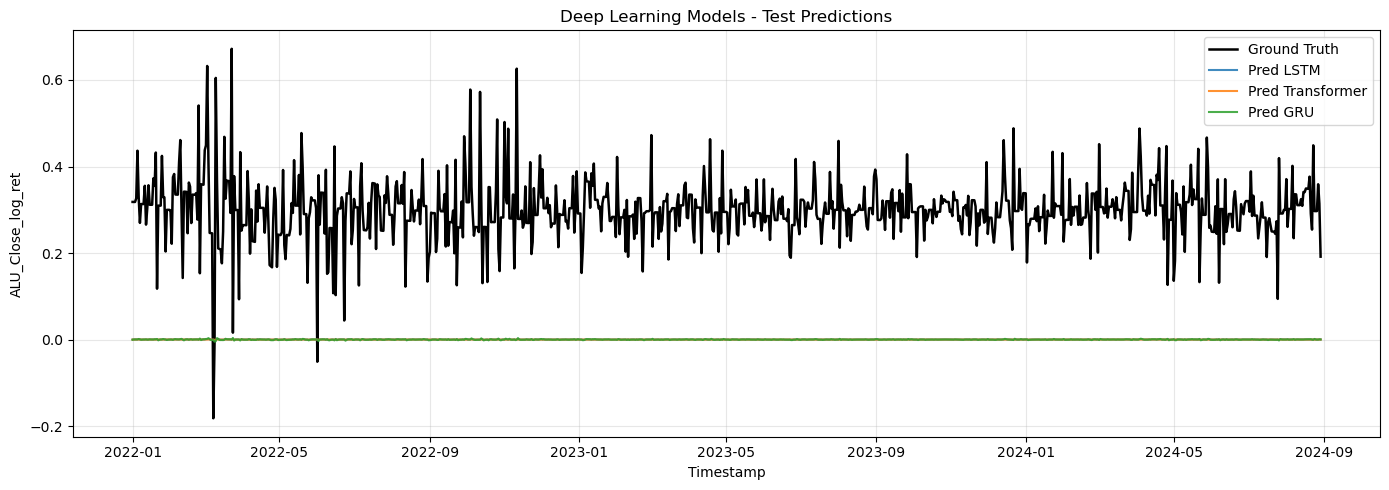

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Tuple

from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.models import RNNModel, TransformerModel

from timeseries_forecast.eval.eval import evaluate

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

TARGET_COL = "ALU_Close_log_ret"
FORECAST_HORIZON = 1
INPUT_CHUNK_LENGTH = 24
OUTPUT_CHUNK_LENGTH = 1
N_EPOCHS = 8
BATCH_SIZE = 64
NORMALIZE_DATA = True

MODEL_NAMES = ["Transformer", "LSTM", "GRU"]
RESULTS_DIR = PROJECT_ROOT / "results" / "darts_deep_models_1h" / "no_contemporaneous_covariates"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if TARGET_COL not in feature_df.columns:
    raise KeyError(f"{TARGET_COL} is missing from feature_df")

# Keep the same cleaned data preparation as Base_Dataframe, but remove contemporaneous leakage.
# The models are trained on the target series only, so the notebook stays compatible across
# the Transformer, LSTM, and GRU implementations in this Darts version.
base_df = (
    feature_df.loc[:, [TARGET_COL]]
    .join(features_df[["ALU_Mode"]], how="inner")
    .sort_index()
)
base_df = base_df.dropna().sort_index()

print(f"Base frame shape: {base_df.shape}")
print(base_df[[TARGET_COL, "ALU_Mode"]].head())


@dataclass
class PreparedSplit:
    target: TimeSeries


@dataclass
class PreparedData:
    train: PreparedSplit
    val: PreparedSplit
    test: PreparedSplit


def _split_frame(mode: str) -> pd.DataFrame:
    split_frame = base_df.loc[base_df["ALU_Mode"] == mode].drop(columns=["ALU_Mode"])
    if split_frame.empty:
        raise ValueError(f"No rows found for mode={mode}")
    return split_frame


def _to_timeseries(split_frame: pd.DataFrame) -> PreparedSplit:
    target_series = TimeSeries.from_series(split_frame[TARGET_COL])
    return PreparedSplit(target=target_series)


def prepare_data() -> PreparedData:
    return PreparedData(
        train=_to_timeseries(_split_frame("Train")),
        val=_to_timeseries(_split_frame("Val")),
        test=_to_timeseries(_split_frame("Test")),
    )


def maybe_scale(prepared: PreparedData):
    if not NORMALIZE_DATA:
        return prepared, None

    target_scaler = Scaler()
    scaled = PreparedData(
        train=PreparedSplit(target=target_scaler.fit_transform(prepared.train.target)),
        val=PreparedSplit(target=target_scaler.transform(prepared.val.target)),
        test=PreparedSplit(target=target_scaler.transform(prepared.test.target)),
    )
    return scaled, target_scaler


def ts_to_series(series: TimeSeries) -> pd.Series:
    if hasattr(series, "to_series"):
        return series.to_series()
    if hasattr(series, "pd_series"):
        return series.pd_series()
    raise AttributeError("Unsupported Darts TimeSeries version.")


def build_transformer() -> TransformerModel:
    return TransformerModel(
        input_chunk_length=INPUT_CHUNK_LENGTH,
        output_chunk_length=OUTPUT_CHUNK_LENGTH,
        n_epochs=N_EPOCHS,
        batch_size=BATCH_SIZE,
        random_state=RANDOM_STATE,
        d_model=64,
        nhead=4,
        num_encoder_layers=2,
        num_decoder_layers=2,
        dim_feedforward=128,
        dropout=0.1,
        force_reset=True,
        save_checkpoints=False,
        pl_trainer_kwargs={"accelerator": "cpu", "devices": 1},
    )


def build_rnn(model_name: str) -> RNNModel:
    return RNNModel(
        model=model_name,
        input_chunk_length=INPUT_CHUNK_LENGTH,
        training_length=INPUT_CHUNK_LENGTH,
        hidden_dim=64,
        n_rnn_layers=2,
        dropout=0.1,
        batch_size=BATCH_SIZE,
        n_epochs=N_EPOCHS,
        random_state=RANDOM_STATE,
        force_reset=True,
        save_checkpoints=False,
        pl_trainer_kwargs={"accelerator": "cpu", "devices": 1},
    )


def fit_and_score(model, prepared: PreparedData, model_label: str) -> Tuple[Dict[str, float | str], pd.DataFrame]:
    train_target = prepared.train.target
    val_target = prepared.val.target
    test_target = prepared.test.target

    train_plus_val_target = train_target.append(val_target)
    full_target = train_plus_val_target.append(test_target)

    model.fit(
        series=train_target,
        val_series=val_target,
        verbose=True,
    )

    val_pred = model.historical_forecasts(
        series=train_plus_val_target,
        start=val_target.start_time(),
        forecast_horizon=FORECAST_HORIZON,
        stride=1,
        retrain=False,
        last_points_only=True,
        verbose=True,
    )
    test_pred = model.historical_forecasts(
        series=full_target,
        start=test_target.start_time(),
        forecast_horizon=FORECAST_HORIZON,
        stride=1,
        retrain=False,
        last_points_only=True,
        verbose=True,
    )

    if NORMALIZE_DATA:
        val_pred = target_scaler.inverse_transform(val_pred)
        test_pred = target_scaler.inverse_transform(test_pred)

    val_true_series = ts_to_series(val_target)
    test_true_series = ts_to_series(test_target)
    val_pred_series = ts_to_series(val_pred)
    test_pred_series = ts_to_series(test_pred)

    val_eval_df = pd.DataFrame({"target": val_true_series.values, "pred": val_pred_series.values}, index=val_true_series.index)
    test_eval_df = pd.DataFrame({"target": test_true_series.values, "pred": test_pred_series.values}, index=test_true_series.index)

    val_score = evaluate(val_eval_df, target_col="target", y_pred_col="pred", do_calculate_directed_accuracy=True)
    test_score = evaluate(test_eval_df, target_col="target", y_pred_col="pred", do_calculate_directed_accuracy=True)

    metrics = {
        "Model": model_label,
        "Val_MAE": val_score.mae,
        "Val_RMSE": val_score.rmse,
        "Val_R2": val_score.r2,
        "Val_Directed_Accuracy": val_score.directed_accuracy,
        "Test_MAE": test_score.mae,
        "Test_RMSE": test_score.rmse,
        "Test_R2": test_score.r2,
        "Test_Directed_Accuracy": test_score.directed_accuracy,
    }

    predictions = pd.DataFrame(
        {
            "timestamp": test_true_series.index,
            "model": model_label,
            "y_true": test_true_series.values,
            "y_pred": test_pred_series.values,
        }
    )
    return metrics, predictions


prepared_data = prepare_data()
prepared_data, target_scaler = maybe_scale(prepared_data)

print(f"Train split: {len(prepared_data.train.target)} samples")
print(f"Val split: {len(prepared_data.val.target)} samples")
print(f"Test split: {len(prepared_data.test.target)} samples")

models = {
    "Transformer": build_transformer(),
    "LSTM": build_rnn("LSTM"),
    "GRU": build_rnn("GRU"),
}

all_metrics = []
all_predictions = []

for model_label, model in models.items():
    print("\n" + "=" * 90)
    print(f"Training {model_label}")
    print("=" * 90)
    metrics, predictions = fit_and_score(model, prepared_data, model_label)
    all_metrics.append(metrics)
    all_predictions.append(predictions)

results_df = pd.DataFrame(all_metrics).sort_values("Test_RMSE").reset_index(drop=True)
predictions_df = pd.concat(all_predictions, ignore_index=True)

display(results_df)

metrics_path = RESULTS_DIR / "dl_models_metrics.csv"
preds_path = RESULTS_DIR / "dl_models_test_predictions.csv"
results_df.to_csv(metrics_path, index=False)
predictions_df.to_csv(preds_path, index=False)
print(f"Saved metrics to: {metrics_path}")
print(f"Saved predictions to: {preds_path}")

plt.figure(figsize=(14, 5))
truth_df = predictions_df[predictions_df["model"] == results_df.iloc[0]["Model"]].sort_values("timestamp")
plt.plot(truth_df["timestamp"], truth_df["y_true"], label="Ground Truth", color="black", linewidth=1.8)
for model_label in results_df["Model"]:
    model_df = predictions_df[predictions_df["model"] == model_label].sort_values("timestamp")
    plt.plot(model_df["timestamp"], model_df["y_pred"], label=f"Pred {model_label}", alpha=0.85)
plt.title("Deep Learning Models - Test Predictions")
plt.xlabel("Timestamp")
plt.ylabel(TARGET_COL)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plot_path = RESULTS_DIR / "dl_models_test_predictions.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
print(f"Saved plot to: {plot_path}")
plt.show()
